In [60]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

In [21]:
df = pd.read_excel(r"/Users/developer/Documents/Current Project/Python/DevArena /Arena-Week-8-CapstoneProject/data/cleaned_data.xlsx")
df

,Invoice,StockCode,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale,Region
0,536365,85123A,6,2.55,17850,United Kingdom,08:26:00,2010,12,1,15.30,Europe
1,536365,71053,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe
2,536365,84406B,8,2.75,17850,United Kingdom,08:26:00,2010,12,1,22.00,Europe
3,536365,84029G,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe
4,536365,84029E,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...
324554,581587,22613,12,0.85,12680,France,12:50:00,2011,12,9,10.20,Europe
324555,581587,22899,6,2.10,12680,France,12:50:00,2011,12,9,12.60,Europe
324556,581587,23254,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe
324557,581587,23255,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe


In [22]:
df_analysis = df.copy()

#### <b>Executive Summary

In [23]:
print("Total Sales:", round(df_analysis['LineSale'].sum(), 2))
print("Total Orders:", df_analysis['Invoice'].nunique())
print("Total Customers:", df_analysis['Customer ID'].nunique())

Total Sales: 3518650.42
Total Orders: 16241
Total Customers: 4145


#### <b>Monthly Sales

In [24]:
df_analysis_sales = df_analysis.groupby(['Year', 'Month']).agg(
    monthly_sales=('LineSale', 'sum')
)
df_analysis_sales

monthly_sales
Year Month               
2010 12        222525.480
2011 1         190620.020
     2         181811.410
     3         241304.890
     4         203338.801
     5         264534.160
     6         239712.260
     7         235349.811
     8         255156.110
     9         389122.172
     10        435540.080
     11        521002.940
     12        138632.290

In [25]:
df_analysis_sales_2011 = df_analysis_sales.xs(2011, level='Year')
df_analysis_sales_2011

,monthly_sales
Month,
1,190620.020
2,181811.410
3,241304.890
4,203338.801
5,264534.160
6,239712.260
7,235349.811
8,255156.110
9,389122.172


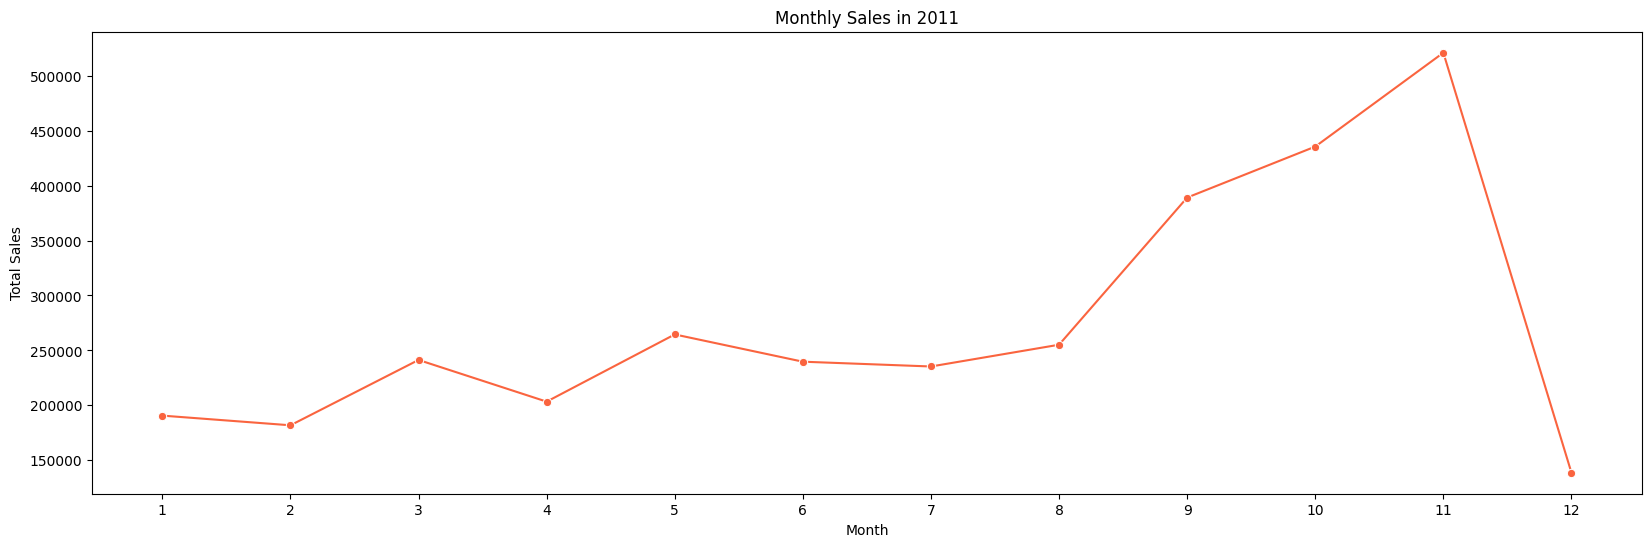

In [84]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=df_analysis_sales_2011, x='Month', y='monthly_sales', marker='o', color='#FA643F')
plt.title('Monthly Sales in 2011')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.show()

#### <b>Region wise Analysis

In [78]:
df_analysis_region = df_analysis.groupby('Region').agg(
    total_sales=('LineSale', 'sum'),
    total_orders=('Invoice', 'nunique')
).sort_values(by='total_sales', ascending=False)
df_analysis_region['pct_sales'] = (
    df_analysis_region['total_sales'] / df_analysis_region['total_sales'].sum()
) * 100
df_analysis_region

,total_sales,total_orders,pct_sales
Region,,,
Europe,3405944.874,15915,99.191395
Middle East,10954.880,23,0.319039
Oceania,6772.000,41,0.197221
North America,4444.650,9,0.129442
Asia,2559.840,14,0.074550
Other,1982.080,8,0.057724
Africa,734.360,1,0.021387
South America,317.340,1,0.009242


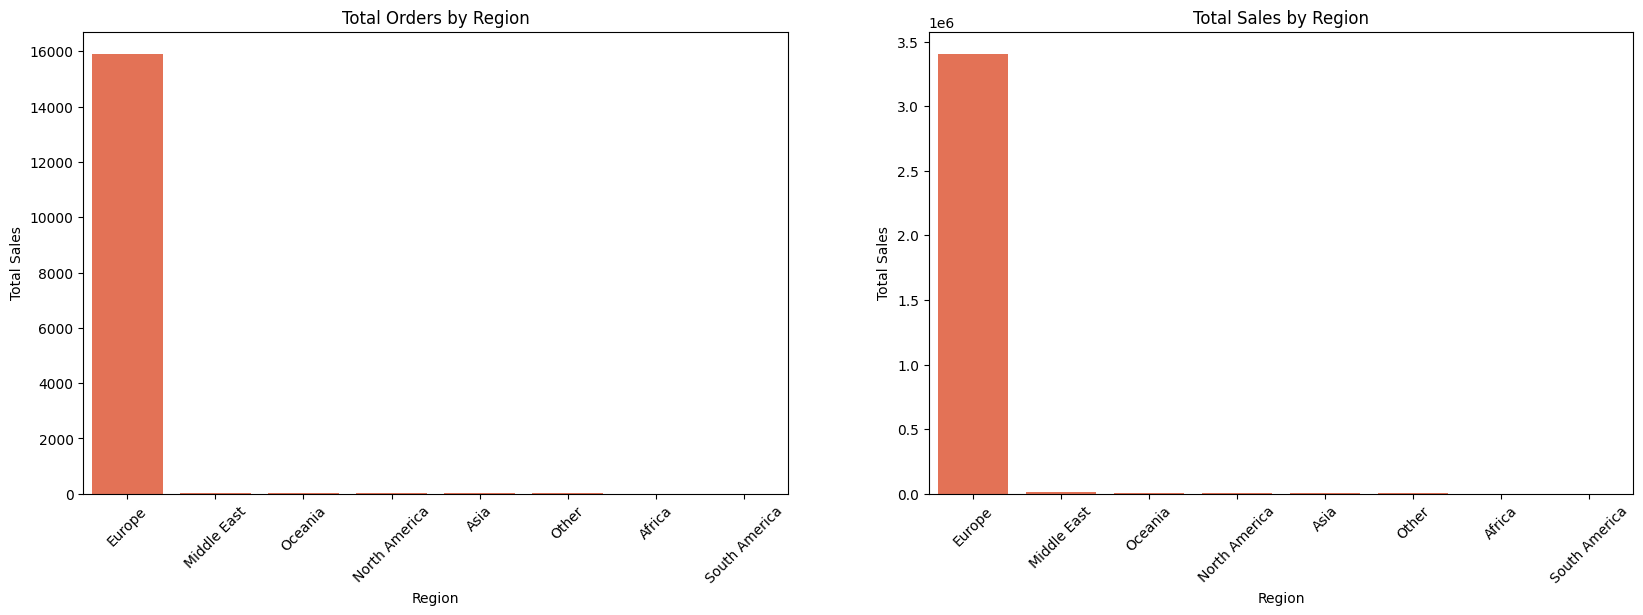

In [83]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=df_analysis_region.reset_index(), x='Region', y='total_orders', color='#FA643F')
plt.title('Total Orders by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(data=df_analysis_region.reset_index(), x='Region', y='total_sales', color='#FA643F')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()

In [ ]:
df_analysis_region = df_analysis.groupby('Region').agg(
    total_sales=('LineSale', 'sum'),
    total_orders=('Invoice', 'nunique')
).sort_values(by='total_sales', ascending=False)
df_analysis_region['pct_sales'] = (
    df_analysis_region['total_sales'] / df_analysis_region['total_sales'].sum()
) * 100
df_analysis_region

,total_sales,total_orders,pct_sales
Region,,,
Europe,3405944.874,15915,99.191395
Middle East,10954.880,23,0.319039
Oceania,6772.000,41,0.197221
North America,4444.650,9,0.129442
Asia,2559.840,14,0.074550
Other,1982.080,8,0.057724
Africa,734.360,1,0.021387
South America,317.340,1,0.009242


#### <b>Country Wise Sales

In [55]:
df_analysis_country = df_analysis.groupby('Country').agg(
    total_sales=('LineSale', 'sum'),
    total_orders=('Invoice', 'nunique'),
    total_customers=('Customer ID', 'nunique')
).sort_values(by='total_sales', ascending=False)
df_analysis_country.head(10)

,total_sales,total_orders,total_customers
Country,,,
United Kingdom,3029944.564,14620,3742
Germany,112641.210,418,91
France,101685.510,357,86
EIRE,83498.730,224,3
Spain,27089.100,80,28
Belgium,26066.740,93,25
Switzerland,22430.000,43,21
Portugal,17439.110,46,19
Norway,11718.070,33,10


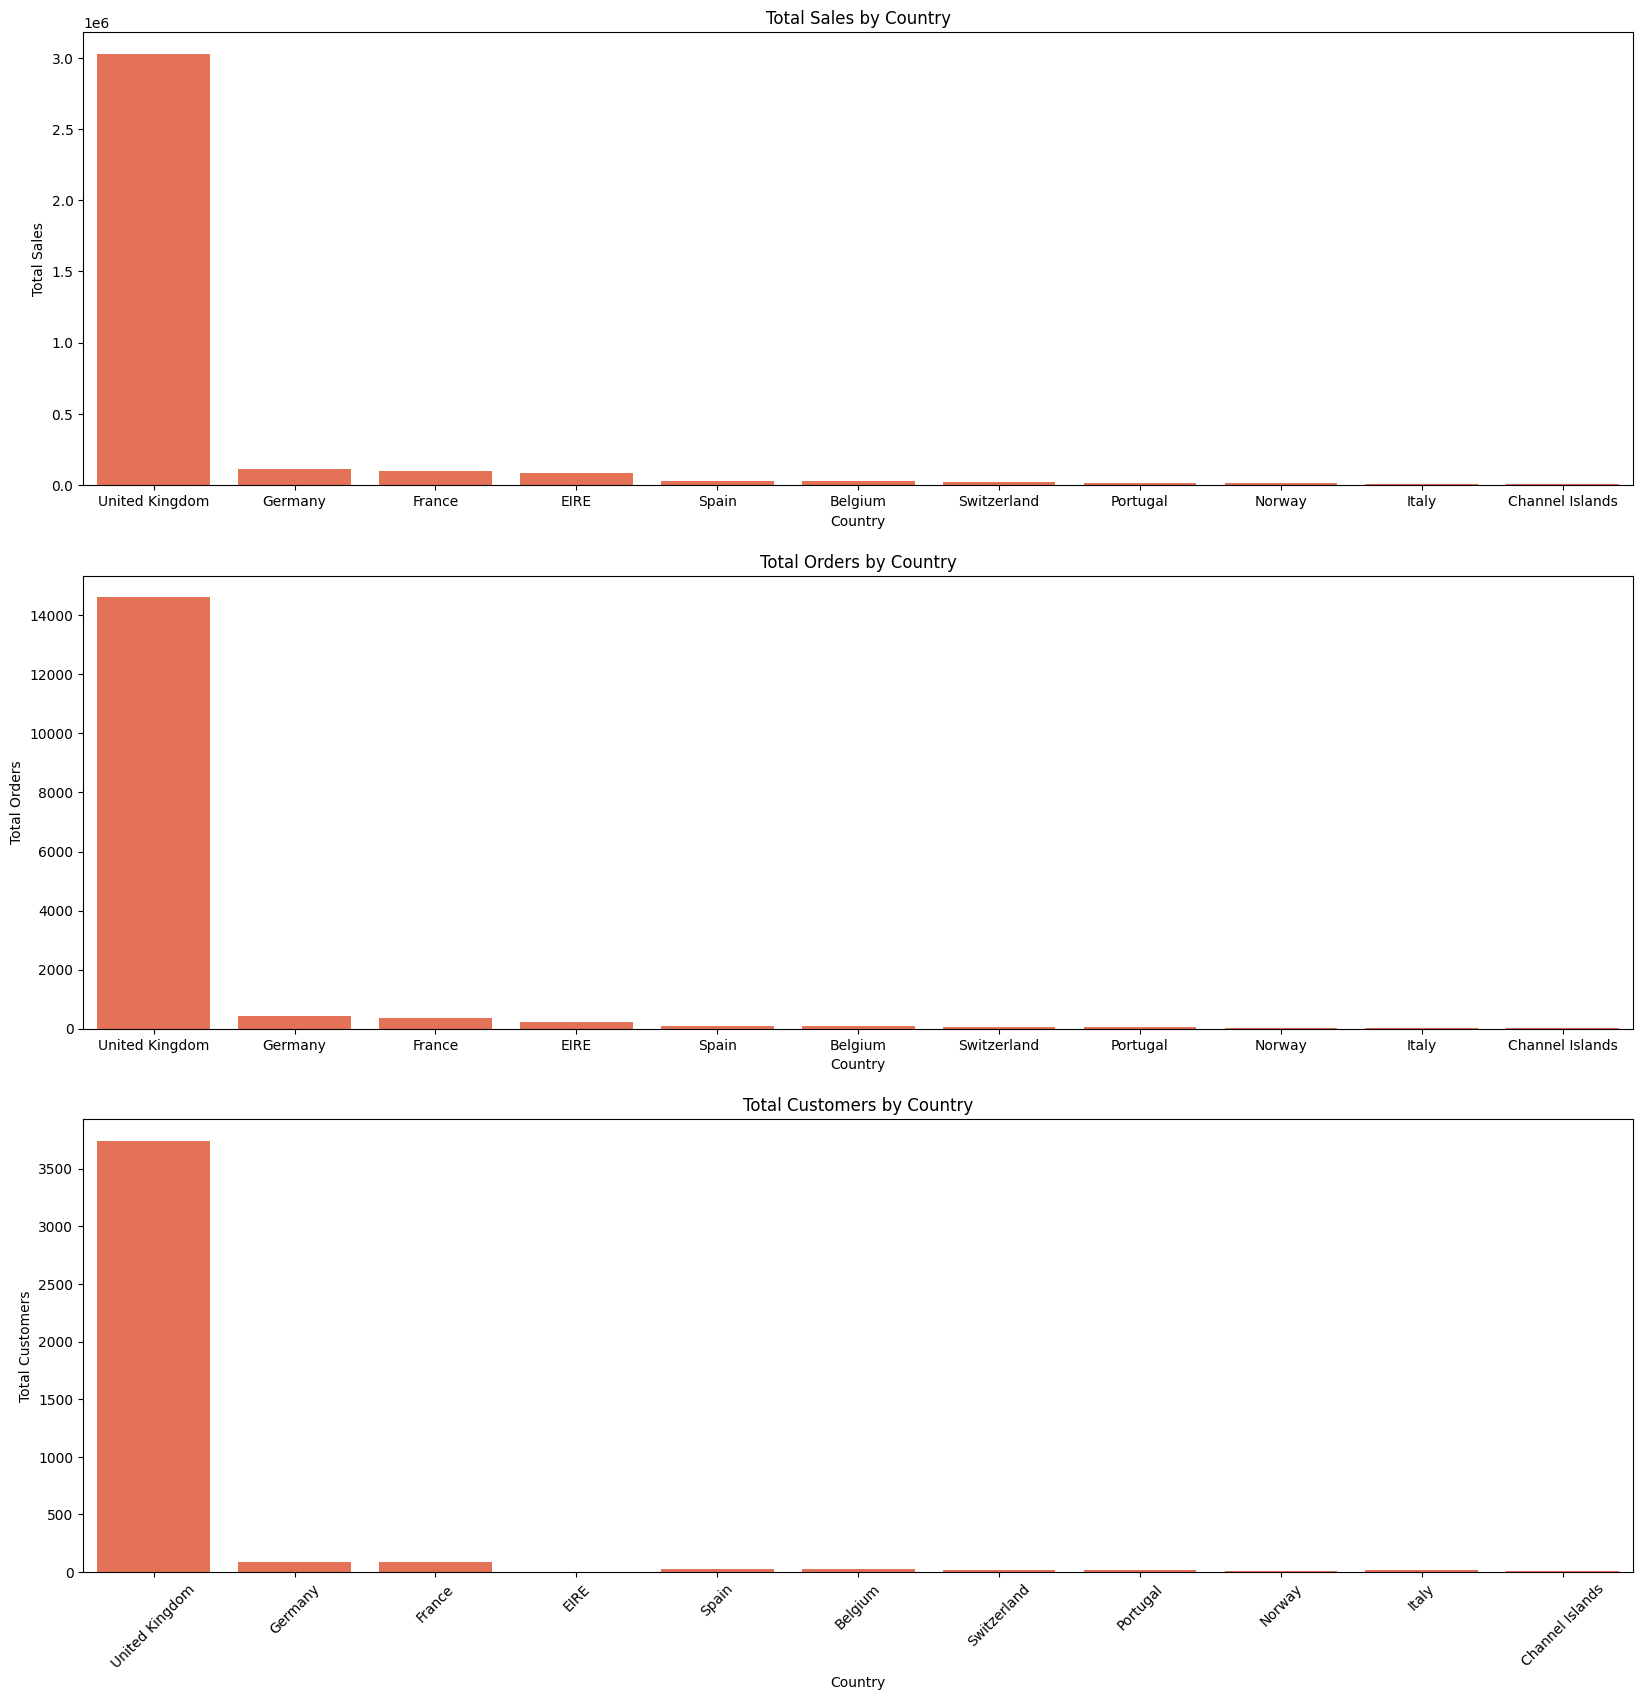

In [85]:
plt.figure(figsize=(20, 20))
plt.subplot(3, 1, 1)
sns.barplot(data=df_analysis_country.reset_index()[:11], x='Country', y='total_sales', color='#FA643F')
plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')

plt.subplot(3, 1, 2)
sns.barplot(data=df_analysis_country.reset_index()[:11], x='Country', y='total_orders', color='#FA643F')
plt.title('Total Orders by Country')
plt.xlabel('Country')
plt.ylabel('Total Orders')

plt.subplot(3, 1, 3)
sns.barplot(data=df_analysis_country.reset_index()[:11], x='Country', y='total_customers', color='#FA643F')
plt.title('Total Customers by Country')
plt.xlabel('Country')
plt.ylabel('Total Customers')

plt.xticks(rotation=45)
plt.show()

#### <b>Quaterly Sales

In [88]:
df_analysis['Quarter'] = df_analysis['Month'].apply(lambda x: f"Q{(x-1)//3 + 1}")
df_analysis

,Invoice,StockCode,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale,Region,Quarter,TimeOfDay
0,536365,85123A,6,2.55,17850,United Kingdom,08:26:00,2010,12,1,15.30,Europe,Q4,Morning
1,536365,71053,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
2,536365,84406B,8,2.75,17850,United Kingdom,08:26:00,2010,12,1,22.00,Europe,Q4,Morning
3,536365,84029G,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
4,536365,84029E,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324554,581587,22613,12,0.85,12680,France,12:50:00,2011,12,9,10.20,Europe,Q4,Afternoon
324555,581587,22899,6,2.10,12680,France,12:50:00,2011,12,9,12.60,Europe,Q4,Afternoon
324556,581587,23254,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe,Q4,Afternoon
324557,581587,23255,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe,Q4,Afternoon


In [89]:
df_analysis_quaters = df_analysis.groupby(['Year', 'Quarter']).agg(
    total_sales=('LineSale', 'sum')
).xs(2011, level='Year')
df_analysis_quaters

,total_sales
Quarter,
Q1,613736.320
Q2,707585.221
Q3,879628.093
Q4,1095175.310


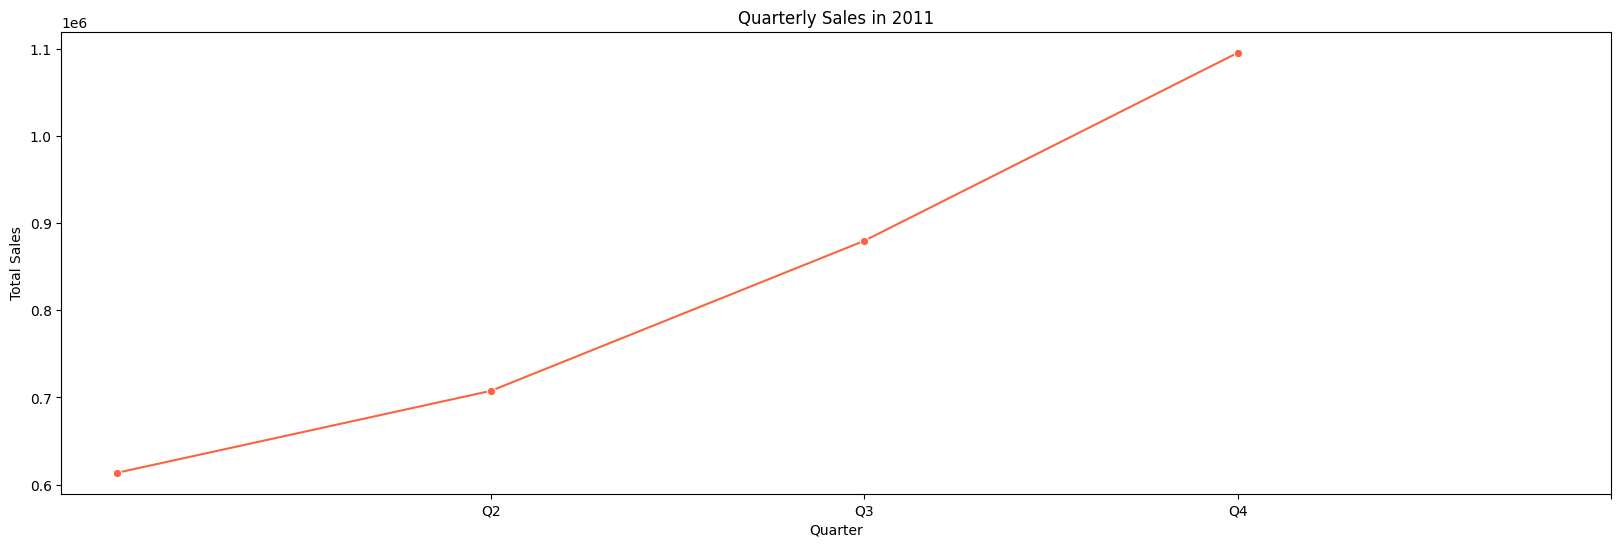

In [90]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=df_analysis_quaters, x='Quarter', y='total_sales', marker='o', color='#FA643F')
plt.title('Quarterly Sales in 2011')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(range(1, 5))
plt.show()

In [91]:
df_analysis_quaters = df_analysis.groupby(['Year', 'Quarter', 'Month']).agg(
    total_sales=('LineSale', 'sum')
).xs(2011, level='Year')
df_analysis_quaters

total_sales
Quarter Month             
Q1      1       190620.020
        2       181811.410
        3       241304.890
Q2      4       203338.801
        5       264534.160
        6       239712.260
Q3      7       235349.811
        8       255156.110
        9       389122.172
Q4      10      435540.080
        11      521002.940
        12      138632.290

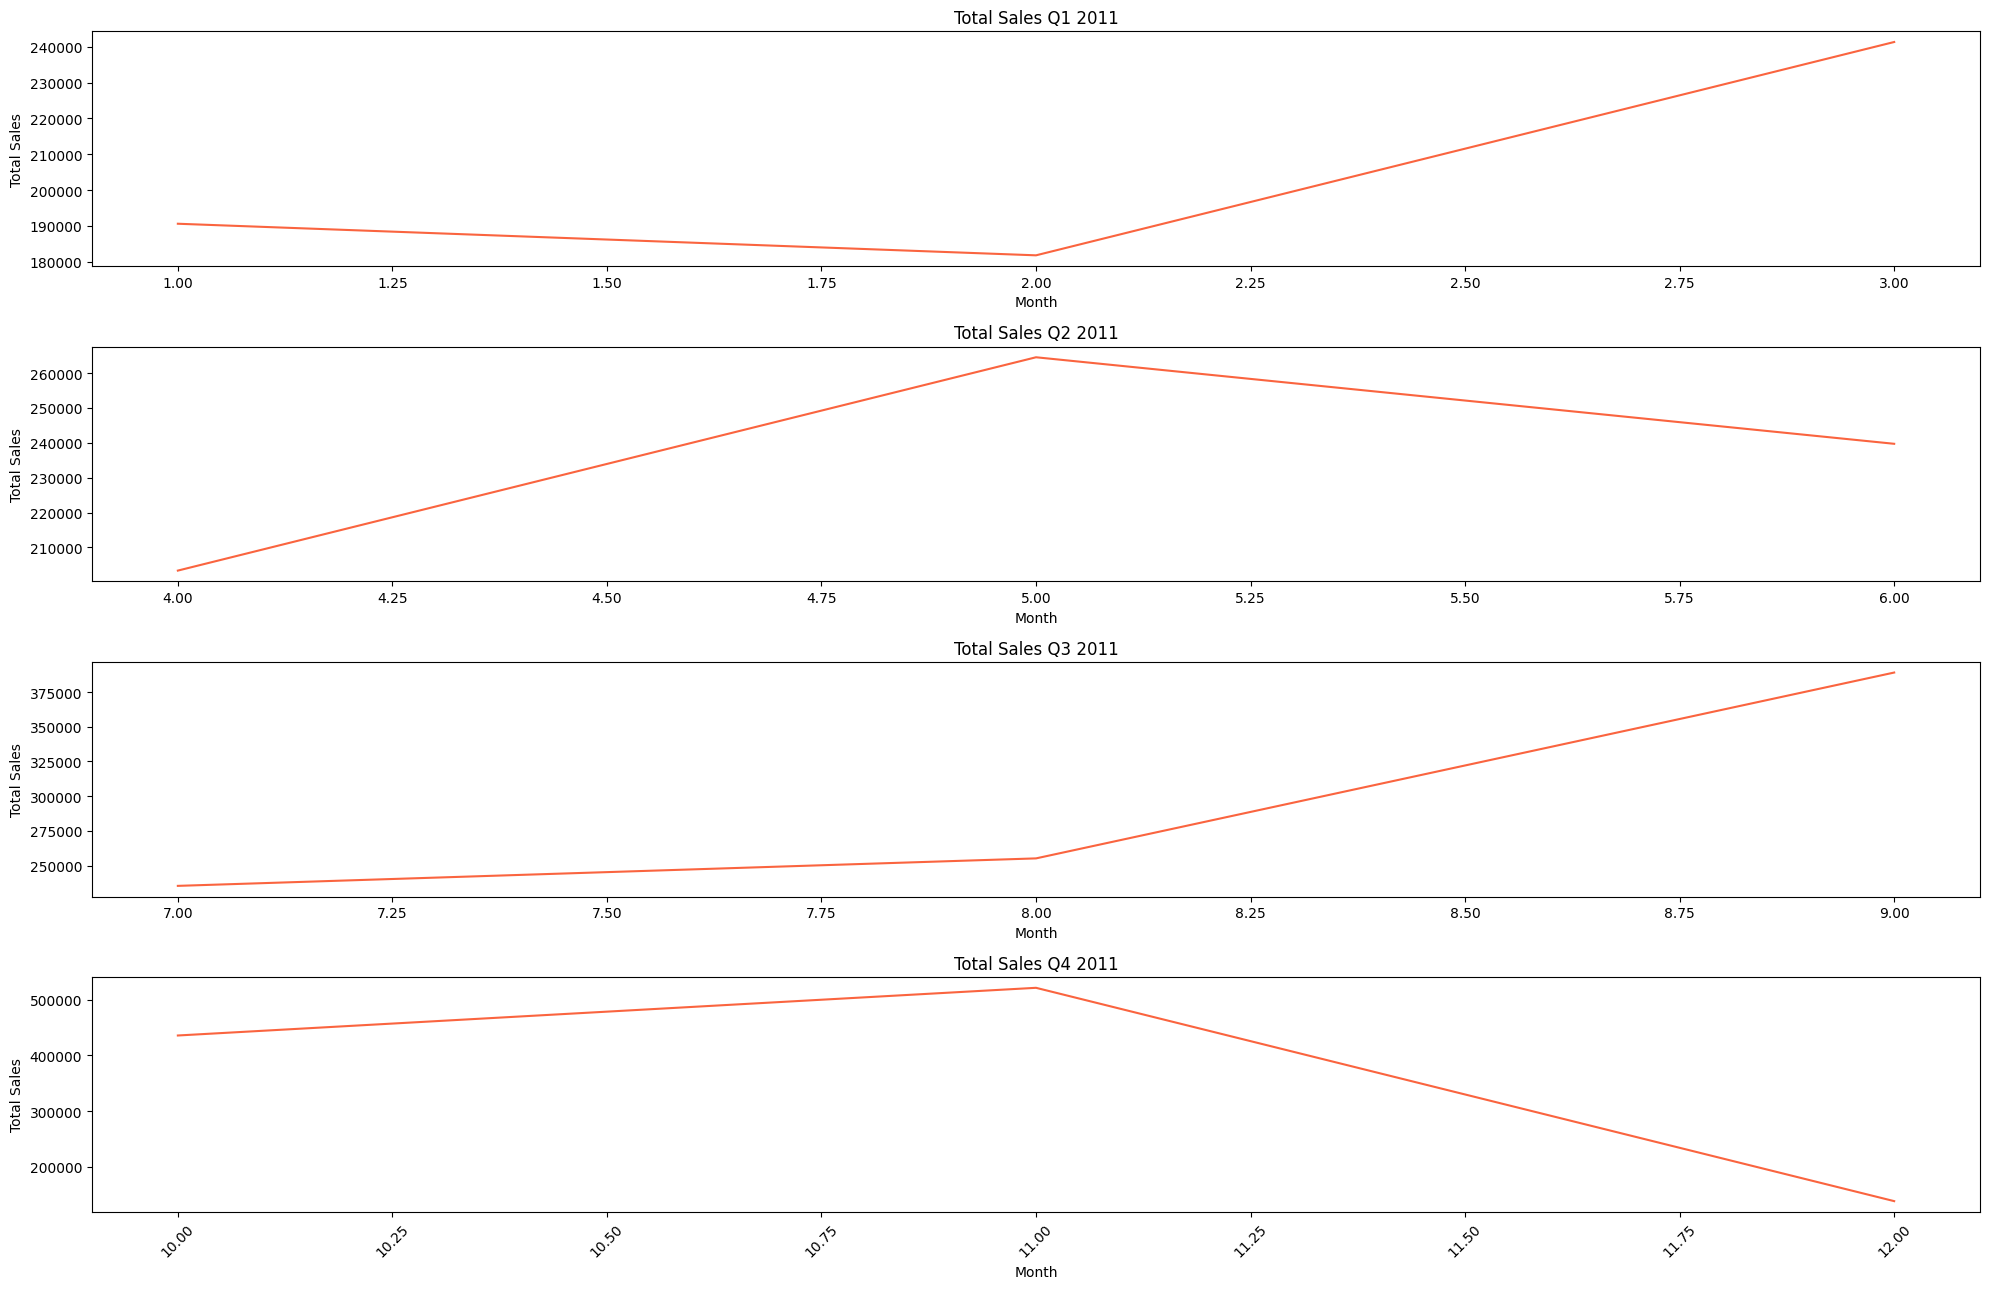

In [92]:
plt.figure(figsize=(20, 13))
plt.subplot(4, 1, 1)
sns.lineplot(data=df_analysis_quaters.xs('Q1', level='Quarter'), x='Month', y='total_sales', color='#FA643F')
plt.title('Total Sales Q1 2011')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.subplot(4, 1, 2)
sns.lineplot(data=df_analysis_quaters.xs('Q2', level='Quarter'), x='Month', y='total_sales', color='#FA643F')
plt.title('Total Sales Q2 2011')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.subplot(4, 1, 3)
sns.lineplot(data=df_analysis_quaters.xs('Q3', level='Quarter'), x='Month', y='total_sales', color='#FA643F')
plt.title('Total Sales Q3 2011')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.subplot(4, 1, 4)
sns.lineplot(data=df_analysis_quaters.xs('Q4', level='Quarter'), x='Month', y='total_sales', color='#FA643F')
plt.title('Total Sales Q4 2011')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
df_analysis_quaters = df_analysis.groupby(['Region','Quarter']).agg(
    total_sales=('LineSale', 'sum')
)
df_analysis_quaters

total_sales
Region        Quarter             
Africa        Q4           734.360
Asia          Q1           711.580
              Q2           425.100
              Q3           538.020
              Q4           885.140
Europe        Q1        596379.100
              Q2        686092.151
              Q3        844998.473
              Q4       1278475.150
Middle East   Q1          3716.270
              Q2           805.470
              Q3          2828.200
              Q4          3604.940
North America Q1           140.540
              Q2           983.380
              Q3          1049.470
              Q4          2271.260
Oceania       Q1          2036.280
              Q2          1124.520
              Q3          2751.900
              Q4           859.300
Other         Q2          1129.040
              Q3           853.040
South America Q2           317.340

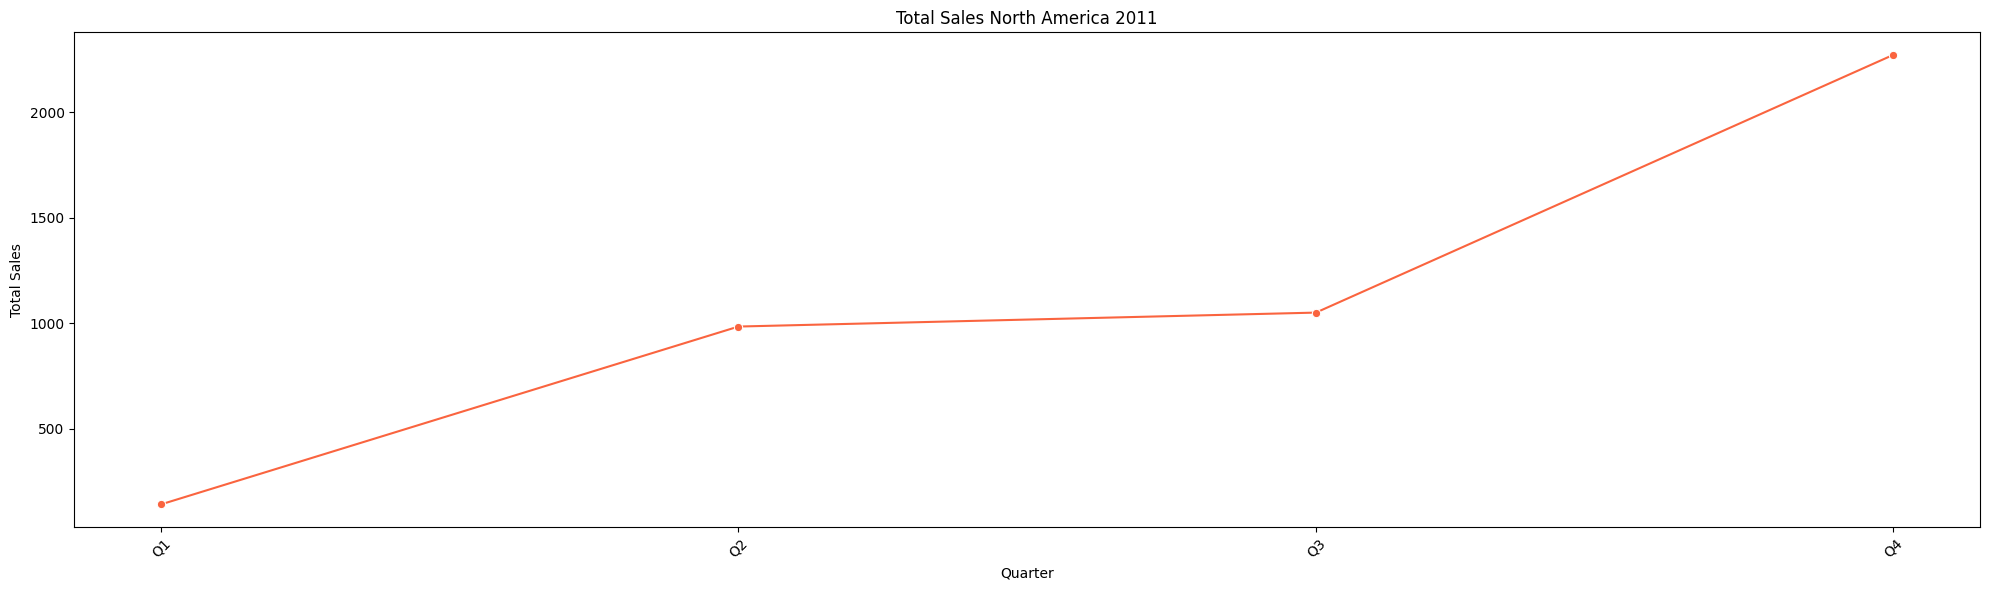

In [96]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=df_analysis_quaters.xs('North America', level='Region'), x='Quarter', y='total_sales', marker='o', color='#FA643F')
plt.title('Total Sales North America 2011')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### <b>Time of Day Sales

In [98]:

df_analysis['TimeOfDay'] = df_analysis['Invoice_Time'].apply(
    lambda x: 'Morning' if 5 <= x.hour < 12
    else 'Afternoon' if 12 <= x.hour < 17
    else 'Evening' if 17 <= x.hour < 21
    else 'Night'
)
df_analysis

,Invoice,StockCode,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale,Region,Quarter,TimeOfDay
0,536365,85123A,6,2.55,17850,United Kingdom,08:26:00,2010,12,1,15.30,Europe,Q4,Morning
1,536365,71053,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
2,536365,84406B,8,2.75,17850,United Kingdom,08:26:00,2010,12,1,22.00,Europe,Q4,Morning
3,536365,84029G,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
4,536365,84029E,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324554,581587,22613,12,0.85,12680,France,12:50:00,2011,12,9,10.20,Europe,Q4,Afternoon
324555,581587,22899,6,2.10,12680,France,12:50:00,2011,12,9,12.60,Europe,Q4,Afternoon
324556,581587,23254,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe,Q4,Afternoon
324557,581587,23255,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe,Q4,Afternoon


In [99]:
df_analysis_timeofday = df_analysis.groupby('TimeOfDay').agg(
    total_sales=('LineSale', 'sum'),
    total_orders=('Invoice', 'nunique')
).round({
    'total_sales': 2
})
df_analysis_timeofday

,total_sales,total_orders
TimeOfDay,,
Afternoon,2180122.85,9966
Evening,152866.73,781
Morning,1185660.84,5495


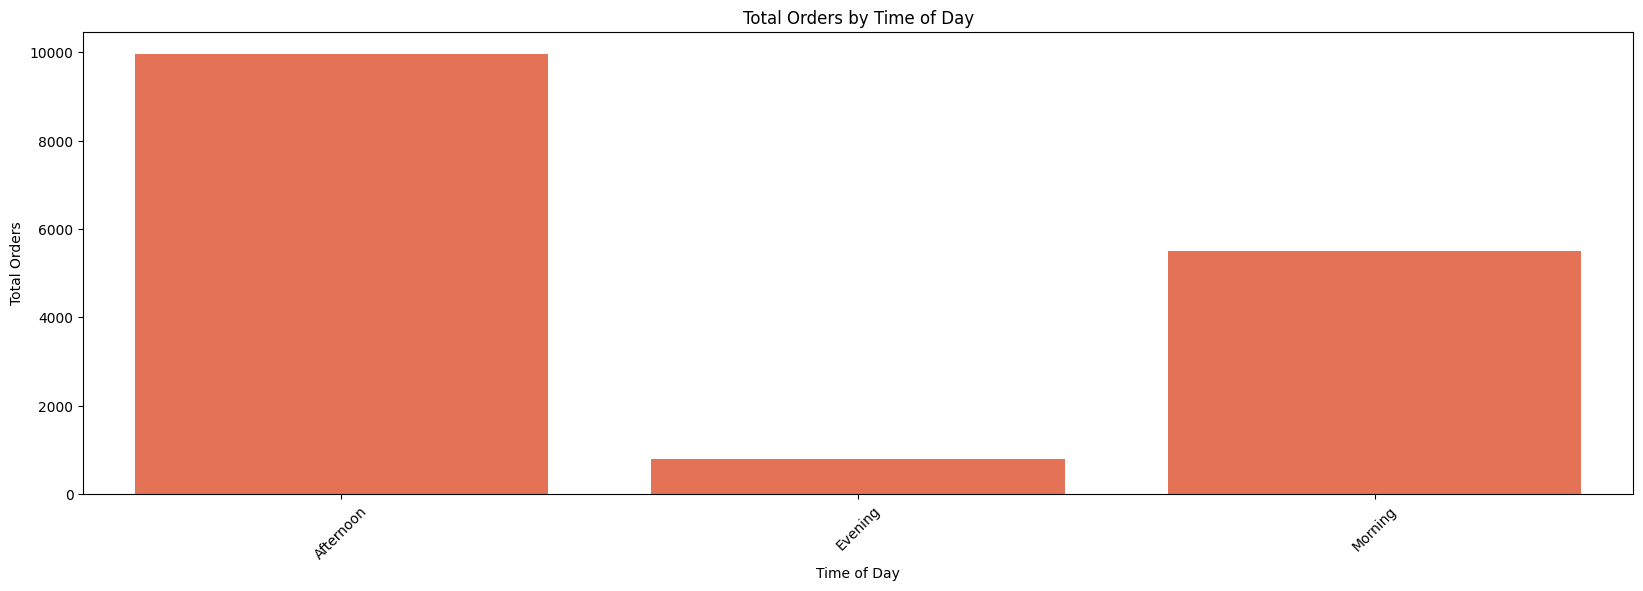

In [100]:
plt.figure(figsize=(20,6))

plt.subplot(1, 1, 1)
sns.barplot(data=df_analysis_timeofday.reset_index(), x='TimeOfDay', y='total_orders', color='#FA643F')
plt.title('Total Orders by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)
plt.show()

In [101]:
df_analysis

,Invoice,StockCode,Quantity,Price,Customer ID,Country,Invoice_Time,Year,Month,Day,LineSale,Region,Quarter,TimeOfDay
0,536365,85123A,6,2.55,17850,United Kingdom,08:26:00,2010,12,1,15.30,Europe,Q4,Morning
1,536365,71053,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
2,536365,84406B,8,2.75,17850,United Kingdom,08:26:00,2010,12,1,22.00,Europe,Q4,Morning
3,536365,84029G,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
4,536365,84029E,6,3.39,17850,United Kingdom,08:26:00,2010,12,1,20.34,Europe,Q4,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324554,581587,22613,12,0.85,12680,France,12:50:00,2011,12,9,10.20,Europe,Q4,Afternoon
324555,581587,22899,6,2.10,12680,France,12:50:00,2011,12,9,12.60,Europe,Q4,Afternoon
324556,581587,23254,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe,Q4,Afternoon
324557,581587,23255,4,4.15,12680,France,12:50:00,2011,12,9,16.60,Europe,Q4,Afternoon


In [44]:
df_analysis.to_excel(r"/Users/developer/Documents/Current Project/Python/DevArena /Arena-Week-8-CapstoneProject/data/cleaned_data.xlsx", index=False)